## Mia Bruno COT6481 Final Project April 24th, 2026

## 1. Problem Statement:
This project attempts to predict whether or not a borrower will default on a loan given financial information about them. By predicting loan defaults institutions can lessen risk. The question to be answered is: Can I determine whether or not an applicant will default on a loan given information available at application time? If so, banks can automatically approve "low-risk" loans and increase interest rates on "high-risk" loans. This model can give loan officers confidence in making the best lending decisions.


## 2. Literature:
The dataset used for this project comes from Kaggle's Loan Default Dataset. This dataset consists of millions of borrowers' demographics and financial attributes. Statistical analysis of financial datasets has proven that these datasets contain non-linear relationships. Also, loan datasets specifically tend to have imbalanced classes with non-defaulters outnumbering defaulters. For my model, I will use Gradient Boosting due to its strong predictive capabilities and SMOTE to evenly distribute training data.

## 3. Modeling Type and Technique: 
Gradient Boosting was chosen as it sequentially improves upon decision trees which makes it ideal for tabular data. I incorporated SMOTE into the Scikit-learn Pipeline to deal with class imbalance. Major factors include income, credit history, and loan terms. I did not include "leakage" variables such as rate_of_interest because they would not be available before approving the loan. (The interest rate is given based on the assessed risk.) Dropping this column allows this model to remain realistic instead of "cheating" with an accuracy of 1.0.

## 4. Implementation

In [8]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import category_encoders as ce

sns.set_theme(style="darkgrid")


In [9]:
# Read and preprocess data
#Load dataset- Kaggle Dataset 
data = pd.read_csv('Loan_Default.csv')

# Show initial data info
print("Initial Data Head:")
print(data.head())
print("\nData Info:")
data.info()
print("\nMissing Values:")
print(data.isnull().sum())

# Drop identifier columns
for col in ['ID', 'LoanID', 'id']:
    if col in data.columns:
        data = data.drop(columns=col)

# Drop leakage columns
leakage_cols = ['rate_of_interest', 'Interest_rate_spread', 'Upfront_charges']
data = data.drop(columns=[col for col in leakage_cols if col in data.columns])


# Define target variable
target_column = 'Status'
X = data.drop(columns=target_column)
y = data[target_column]

# Handle missing values
for col in X.columns:
    if X[col].dtype in [np.float64, np.int64]:
        X[col] = X[col].fillna(X[col].median())
    else:
        X[col] = X[col].fillna(X[col].mode()[0])

# Identify categorical features
categorical_features = X.select_dtypes(include='object').columns.tolist()

# Encode categorical variables
if 'age' in categorical_features:
    age_map = {
        '25-34': 29.5,
        '35-44': 39.5,
        '45-54': 49.5,
        '55-64': 59.5,
        '65-74': 69.5,
        '75+': 75
    }
    X['age'] = X['age'].map(age_map)

# One-hot encode other categorical features
for col in categorical_features:
    if col != 'age':
        ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
        encoded = ohe.fit_transform(X[[col]])
        encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out([col]))
        X = pd.concat([X.drop(columns=col), encoded_df], axis=1)

# Convert all data to numeric
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())

Initial Data Head:
      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \
0          EXP           7

In [10]:
# Split into train/test and handle class imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=7
)

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Class distribution in y_train:\n{y_train.value_counts(normalize=True)}")
print(f"Class distribution in y_test:\n{y_test.value_counts(normalize=True)}")


Shape of X_train: (118936, 61)
Shape of X_test: (29734, 61)
Class distribution in y_train:
Status
0    0.753557
1    0.246443
Name: proportion, dtype: float64
Class distribution in y_test:
Status
0    0.753548
1    0.246452
Name: proportion, dtype: float64


In [11]:
# Model training with pipeline  and SMOTE
classifier = GradientBoostingClassifier(random_state=42)
pipeline = Pipeline(steps=[
    ('smote', SMOTE(random_state=9)),
    ('classifier', classifier)
])

In [12]:
# Fit model
print("\nTraining the model with SMOTE handling class imbalance...")
pipeline.fit(X_train, y_train)
print("Training complete.")


Training the model with SMOTE handling class imbalance...
Training complete.



--- Performance on Training Set ---
Accuracy: 0.8858545772516311
Precision: 0.9418702611625948
Recall: 0.5721401521613046
F1-Score: 0.7118600899906613
ROC AUC: 0.8836253720560447

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93     89625
           1       0.94      0.57      0.71     29311

    accuracy                           0.89    118936
   macro avg       0.91      0.78      0.82    118936
weighted avg       0.89      0.89      0.88    118936



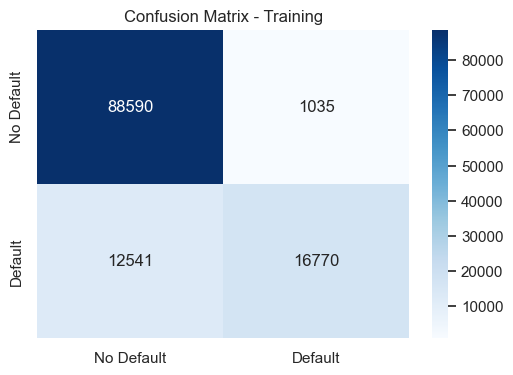

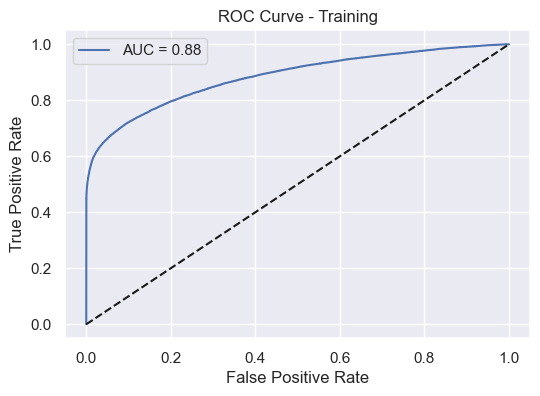

In [13]:
# Evaluation on training set
y_train_pred = pipeline.predict(X_train)
y_train_proba = pipeline.predict_proba(X_train)[:, 1]

print("\n--- Performance on Training Set ---")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision:", precision_score(y_train, y_train_pred))
print("Recall:", recall_score(y_train, y_train_pred))
print("F1-Score:", f1_score(y_train, y_train_pred))
print("ROC AUC:", roc_auc_score(y_train, y_train_proba))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))

# Confusion matrix for training
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Training')
plt.show()

# ROC curve for training
fpr, tpr, _ = roc_curve(y_train, y_train_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_train, y_train_proba):.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Training')
plt.legend()
plt.show()


--- Performance on Test Set ---
Accuracy: 0.8878052061612969
Precision: 0.9459338695263628
Recall: 0.5777838427947598
F1-Score: 0.7173839376482548
ROC AUC: 0.8870182804229761

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.99      0.93     22406
           1       0.95      0.58      0.72      7328

    accuracy                           0.89     29734
   macro avg       0.91      0.78      0.82     29734
weighted avg       0.89      0.89      0.88     29734



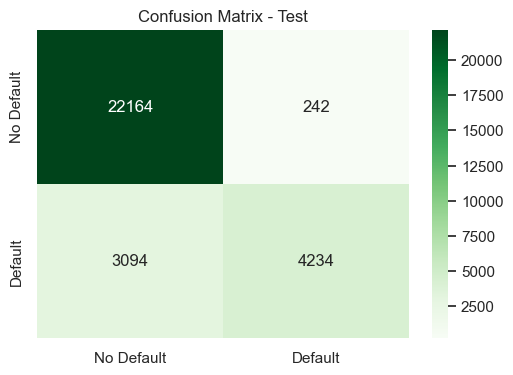

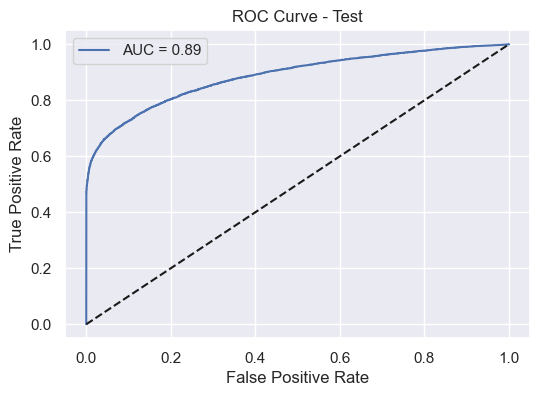

In [14]:
#  Predictions and evaluation on test set
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("\n--- Performance on Test Set ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix for test
cm_test = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Test')
plt.show()

# ROC curve for test
fpr_t, tpr_t, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,4))
plt.plot(fpr_t, tpr_t, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test')
plt.legend()
plt.show()


Performing GridSearchCV for hyperparameter tuning...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}
Best F1 score: 0.7435976875352297

--- Performance of Tuned Model on Test Set ---
Accuracy: 0.8964148785901661
Precision: 0.9308316430020284
Recall: 0.6262281659388647
F1-Score: 0.7487355196606298
ROC AUC: 0.8982761697632847

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.98      0.93     22406
           1       0.93      0.63      0.75      7328

    accuracy                           0.90     29734
   macro avg       0.91      0.81      0.84     29734
weighted avg       0.90      0.90      0.89     29734

Specificity: 0.984780862269035


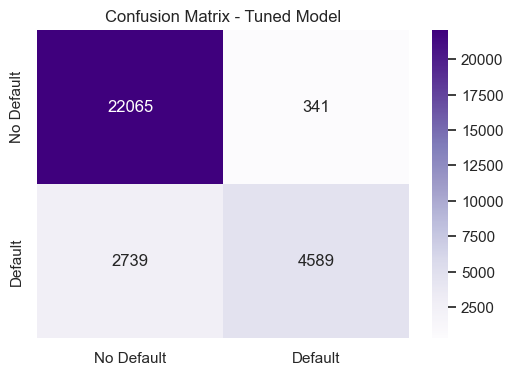

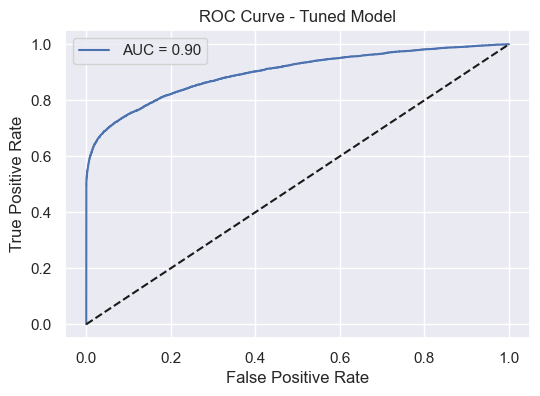

In [15]:
# Hyperparameter tuning with GridSearchCV
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.01, 0.1],
    'classifier__max_depth': [3, 5]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=1)
print("\nPerforming GridSearchCV for hyperparameter tuning...")
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best F1 score:", grid.best_score_)

# Evaluate the best model
best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

print("\n--- Performance of Tuned Model on Test Set ---")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall:", recall_score(y_test, y_pred_tuned))
print("F1-Score:", f1_score(y_test, y_pred_tuned))
print("ROC AUC:", roc_auc_score(y_test, y_proba_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

# Confusion matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
specificity = cm_tuned[0,0] / (cm_tuned[0,0] + cm_tuned[0,1])
print("Specificity:", specificity)

plt.figure(figsize=(6,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix - Tuned Model')
plt.show()

# ROC for tuned model
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)
plt.figure(figsize=(6,4))
plt.plot(fpr_tuned, tpr_tuned, label=f'AUC = {roc_auc_score(y_test, y_proba_tuned):.2f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Model')
plt.legend()
plt.show()

## 5. Observations: 


When initially testing, my model returned accuracy of 1.0. After some further investigation, I realized that this was caused by data leakage on certain interest rate variables. I removed those "future" features and ended up with what I believe to be a realistic and reliable performance with an ROC AUC score of .88. The model has an incredible Precision of .94 for defaults which means the model is very accurate when it predicts that a particular borrower is HIGH risk. Although the Recall is low (.57) indicating that the model does not like to give defaults, that high precision is extremely important to banks so they do not upset good customers by being flooded with false positives. GridSearchCV helped me find that my model had the best balance with a max_depth of 5 and 200 estimators.


## 6. References:

1. Loan Default Prediction Dataset. (2022). Kaggle. https://www.kaggle.com/datasets/yasserh/loan-default-dataset
2. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Applications in Python* (2nd ed.). Springer. https://www.statlearning.com
3. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer. https://hastie.su.domains/ElemStatLearn/
4. Géron, A. (2019). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (2nd ed.). O'Reilly Media.
5. GeeksforGeeks. (2023). *Gradient boosting in ML*. https://www.geeksforgeeks.org/ml-gradient-boosting/
6. GeeksforGeeks. (2023). *SMOTE for imbalanced classification with Python*. https://www.geeksforgeeks.org/smote-for-imbalanced-classification-with-python/
7. logistic_regression workbook- Ozdag, M. (2025). logistic_regression [Jupyter Notebook]. University of Central Florida.
8. seaborn_coding workbook- Ozdag, M. (2025). seaborn_coding [Jupyter Notebook]. University of Central Florida.